# Detecting Regime Change in Time Series Data 

#### This notebook detects structural changes (regime switches) in a time series using a Markov-Switching Model. The model below uses daily log returns of apple stock.



## 1. Introduction 
---
A regime change occurs when the statistical behavior of the data shifts over time. In financial data, this usually means periods of low volatility alternate with periods of high volatility. 

The Markov Switching Model detects these hidden states and estimates when the system changes from one regime to another.

### Technical Definition
A regime-switching model assumes the time series behaves differently depending on an unobserved state (or regime).

For example, a stock return series may alternate between:

- Regime 1: Low volatility / normal market
- Regime 2: High volatility / crisis market

The most common model is the two-state Markov Switching Model:

$$ y_t = \mu_{S_t} + \varepsilon_t $$

where

$$ \varepsilon_t \sim N(0,\sigma_{S_t}^2) $$

and

$$ S_t \in \{1,2\} $$



The hidden regime follows a first-order Markov chain:
$$
P(S_t = j \mid S_{t-1} = i) = p_{ij}
$$
Transition matrix:
$$
P=
\begin{bmatrix}
p_{11} & p_{12} \\
p_{21} & p_{22}
\end{bmatrix}
$$

with
$$
p_{11} + p_{12} = 1
$$

$$
p_{21} + p_{22} = 1
$$

#### Definition of term

<table style="margin-left: 0;">
<tr><th>Symbol</th><th>Meaning</th></tr>
<tr><td>$y_t$</td><td>Observed time series value at time $t$</td></tr>
<tr><td>$S_t$</td><td>Hidden regime at time $t$</td></tr>
<tr><td>$\mu_{S_t}$</td><td>Mean of the series in regime $S_t$</td></tr>
<tr><td>$\sigma_{S_t}^2$</td><td>Variance in regime $S_t$</td></tr>
<tr><td>$p_{ij}$</td><td>Probability of moving from regime $i$ to regime $j$</td></tr>
</table>




### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from arch import arch_model
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8-darkgrid')

## 2. Data Import and Preparation
---

In [3]:
start = '2015-01-01'
end   = '2025-01-01'

df = yf.download('AAPL', start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [4]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532713,24.064276,23.346667,23.984541,257142000
2015-01-06,23.534931,23.794068,23.173911,23.596947,263188400
2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
2015-01-08,24.781897,24.839483,24.075361,24.192749,237458000
...,...,...,...,...,...
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100


In [5]:
# Keep adjusted close
prices = df['Close']

# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Convert to percentage for interpretability and numerical stability
returns = 100 * returns

returns.name = 'Return'

returns.head()

Ticker,AAPL
Date,
2015-01-05,-2.857646
2015-01-06,0.009426
2015-01-07,1.392503
2015-01-08,3.770263
2015-01-09,0.107178


## 3. Exploratory Analysis
---

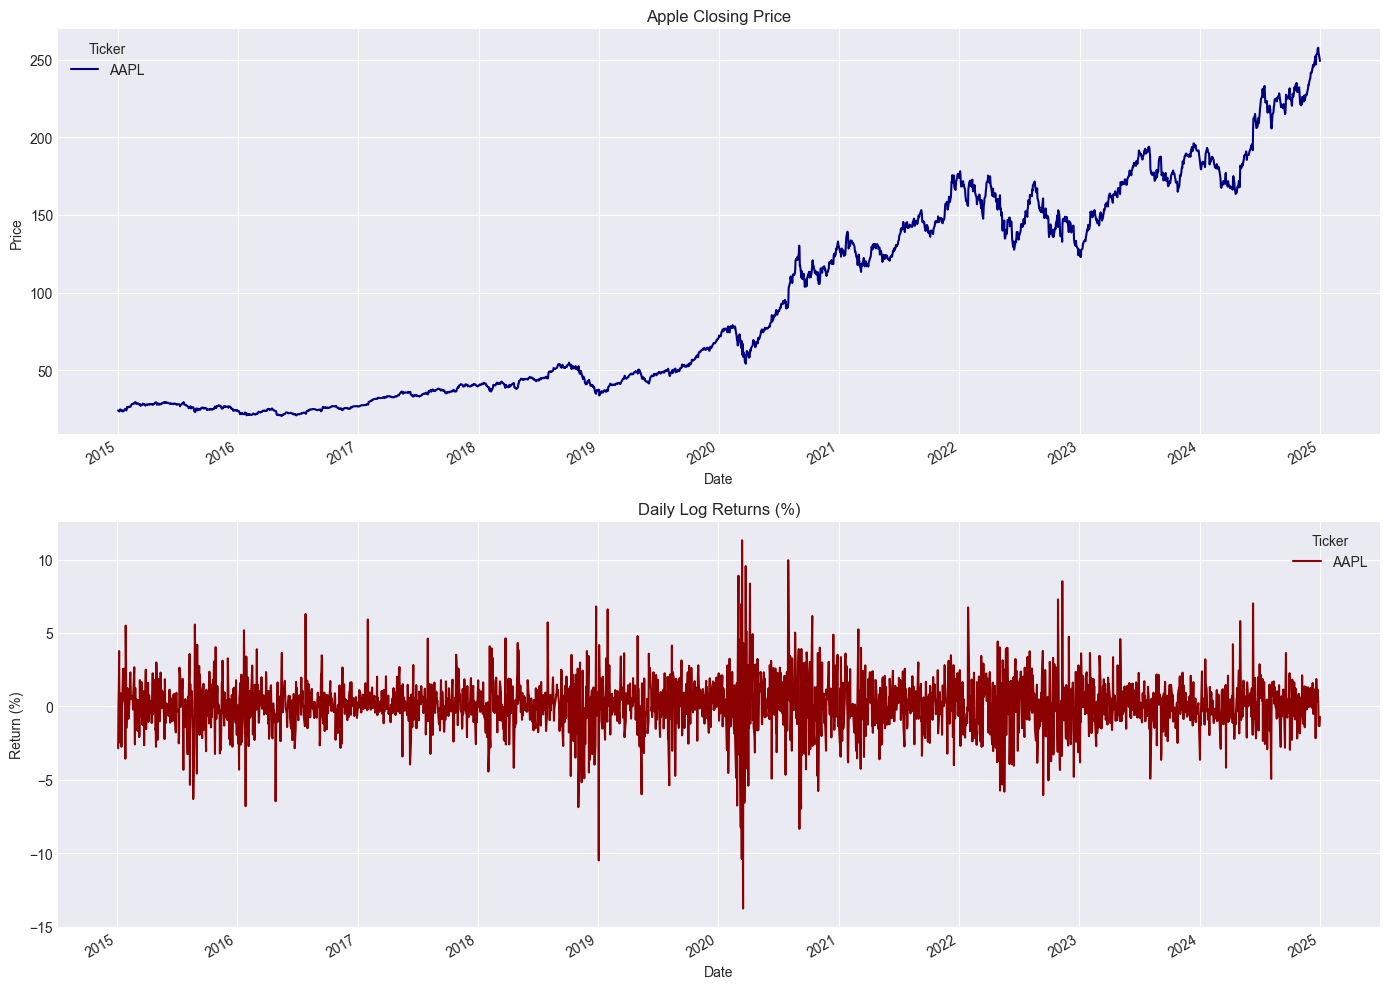

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

prices.plot(ax=ax[0], color='navy')
ax[0].set_title('Apple Closing Price')
ax[0].set_ylabel('Price')

returns.plot(ax=ax[1], color='darkred')
ax[1].set_title('Daily Log Returns (%)')
ax[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.show()

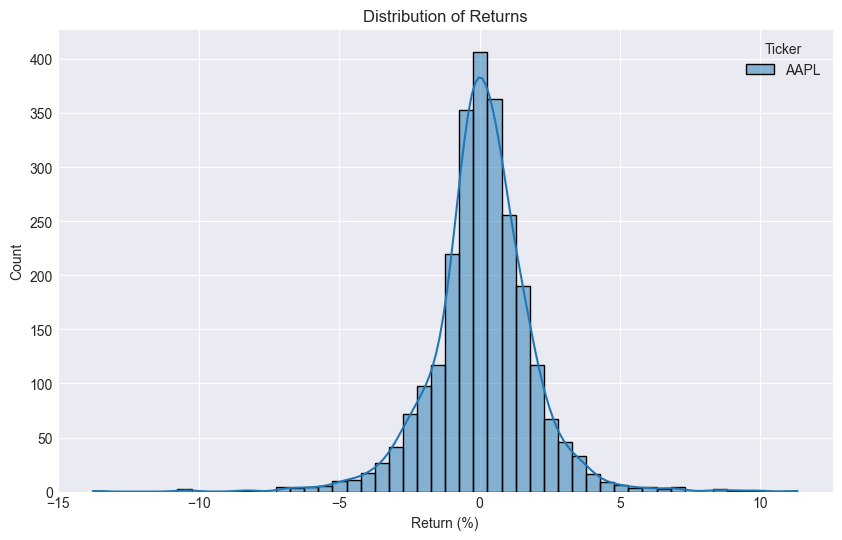

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(returns, bins=50, kde=True)
plt.title('Distribution of Returns')
plt.xlabel('Return (%)')
plt.show()

<Figure size 1000x500 with 0 Axes>

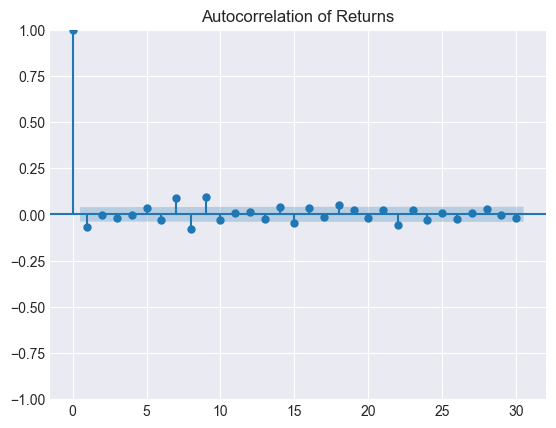

In [8]:
plt.figure(figsize=(10,5))
plot_acf(returns, lags=30)
plt.title('Autocorrelation of Returns')
plt.show()

### 4. Benchmark Model GARCH(1,1)

---

In [9]:
# Use returns (make sure it's a 1D series, not dataframe)
garch_model = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1)

garch_result = garch_model.fit(update_freq=5)

print(garch_result.summary())

Iteration:      5,   Func. Count:     37,   Neg. LLF: 4792.755303928907
Iteration:     10,   Func. Count:     63,   Neg. LLF: 4789.109510464201
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4789.109509275764
            Iterations: 12
            Function evaluations: 72
            Gradient evaluations: 12
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4789.11
Distribution:                  Normal   AIC:                           9586.22
Method:            Maximum Likelihood   BIC:                           9609.54
                                        No. Observations:                 2515
Date:                Mon, Apr 20 2026   Df Residuals:                     2514
Time:          

## 5. Regime Switching Model
---
We estimate a two-regime model where both the mean and variance may change across regimes.

In [10]:
model = MarkovRegression(
    returns,
    k_regimes=2,
    trend='c',
    switching_variance=True
)

results = model.fit()
print(results.summary())

C:\Users\oriol\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                   AAPL   No. Observations:                 2515
Model:               MarkovRegression   Log Likelihood               -4747.704
Date:                Mon, 20 Apr 2026   AIC                           9507.408
Time:                        17:49:01   BIC                           9542.388
Sample:                             0   HQIC                          9520.103
                               - 2515                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1588      0.031      5.072      0.000       0.097       0.220
sigma2         1.2833      0.084     15.293      0.0

### Parameters Calibrated by the Model

The model estimates:

- Regime 0 mean: $\mu_0$
- Regime 1 mean: $\mu_1$

- Regime 0 variance: $\sigma_0^2$
- Regime 1 variance: $\sigma_1^2$

- Transition probabilities: $p_{00}, p_{01}, p_{10}, p_{11}$

Extracting them:

In [11]:
params = results.params

mu_0 = params['const[0]']
mu_1 = params['const[1]']

sigma_0 = np.sqrt(params['sigma2[0]'])
sigma_1 = np.sqrt(params['sigma2[1]'])

p00 = float(params['p[0->0]'])
p10 = float(params['p[1->0]'])

p01 = 1 - p00
p11 = 1 - p10

print('Regime 0 Mean:', mu_0)
print('Regime 1 Mean:', mu_1)
print('Regime 0 Std Dev:', sigma_0)
print('Regime 1 Std Dev:', sigma_1)
print('Transition Matrix:')
print([[p00, p01], [p10, p11]])

Regime 0 Mean: 0.15878896931824432
Regime 1 Mean: -0.06832596854972584
Regime 0 Std Dev: 1.132828003442428
Regime 1 Std Dev: 2.805950570079792
Transition Matrix:
[[0.9573428657810328, 0.04265713421896722], [0.10330224473534666, 0.8966977552646533]]


---

#### Interpretation:

- $\sigma_1 > \sigma_0$, regime 1 is the high-volatility regime.  
- $p_{11}$ is close to 1, once the process enters regime 1, it tends to stay there.
- $p_{00}$ is close to 1, once the process enters regime 0, it tends to stay there. 
- $\mu_1 < \mu_0$, average returns are lower during the high-volatility regime.  

The Markov switching model identifies two distinct regimes in Apple stock returns, mainly differentiated by *volatility rather than mean returns*. 
- **Regime 0** represents a low-volatility state with a small positive mean return (0.1588%) and relatively stable fluctuations (σ ≈ 1.13%).
- **Regime 1** represents a high-volatility state (σ ≈ 2.81%), but its mean return is statistically insignificant, indicating no clear directional bias.

Overall, the results suggest that Apple’s returns are driven primarily by volatility clustering rather than bullish or bearish shifts in mean returns. 

The high persistence in both regimes indicates that market conditions tend to remain stable within each volatility state for extended periods.

The expected duration of regime $i$ is:

$$
\mathbb{E}[\text{duration in regime } i] = \frac{1}{1 - p_{ii}}
$$

In [12]:
duration_regime0 = 1 / (1 - p00)
duration_regime1 = 1 / (1 - p11)

print('Expected duration Regime 0:', duration_regime0)
print('Expected duration Regime 1:', duration_regime1)

Expected duration Regime 0: 23.442737500058232
Expected duration Regime 1: 9.680331754280191


## 6. Visual Representation of Regimes
---

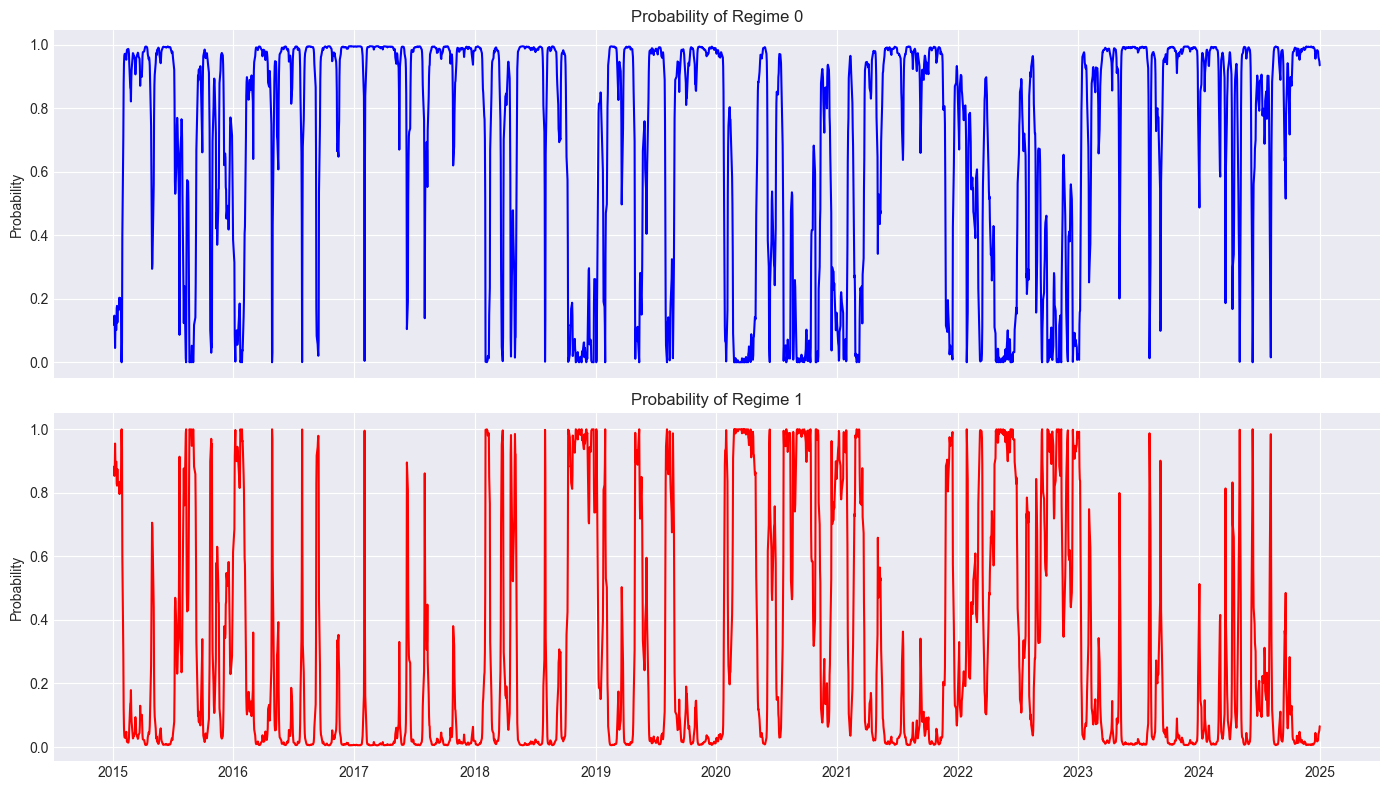

In [13]:
smoothed_probs = results.smoothed_marginal_probabilities

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(smoothed_probs[0], color='blue')
ax[0].set_title('Probability of Regime 0')
ax[0].set_ylabel('Probability')

ax[1].plot(smoothed_probs[1], color='red')
ax[1].set_title('Probability of Regime 1')
ax[1].set_ylabel('Probability')

plt.tight_layout()
plt.show()

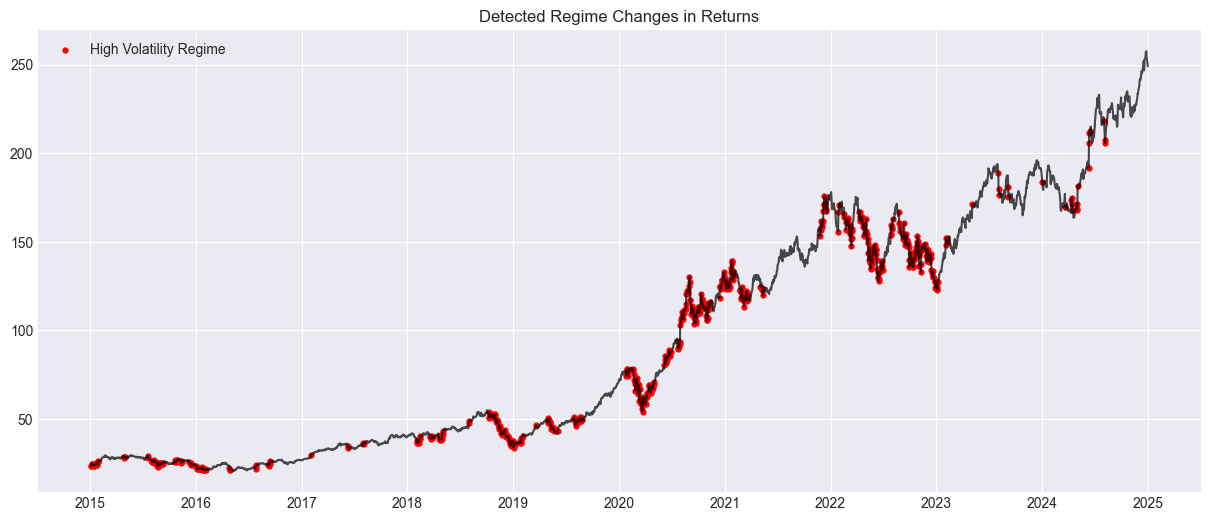

In [14]:
regime = (smoothed_probs[1] > 0.5).astype(int)
New_prices = prices[1:]

plt.figure(figsize=(15,6))
plt.plot(New_prices.index, New_prices, color='black', alpha=0.7)

plt.scatter(
    New_prices.index[regime == 1],
    New_prices[regime == 1],
    color='red',
    label='High Volatility Regime',
    s=12
)

plt.title('Detected Regime Changes in Returns')
plt.legend()
plt.show()

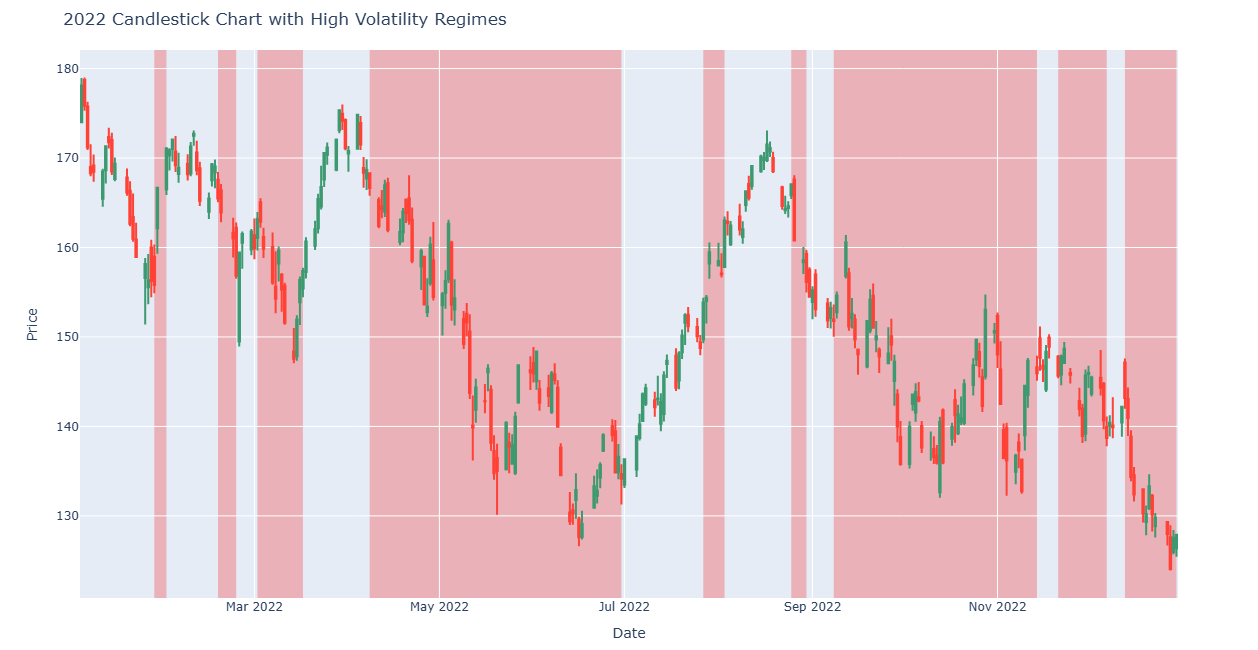

In [32]:
df_2022 = df.loc["2022"].copy()
df_2022.columns = df_2022.columns.droplevel(1)
regime_2022 = regime.loc[df_2022.index]

fig = go.Figure(data=[go.Candlestick(
    x=df_2022.index,
    open=df_2022['Open'],
    high=df_2022['High'],
    low=df_2022['Low'],
    close=df_2022['Close']
)])

mask = regime_2022.eq(1)
groups = (mask != mask.shift()).cumsum()

for _, g in mask.groupby(groups):
    if g.iloc[0]:
        fig.add_vrect(
            x0=g.index[0], x1=g.index[-1],
            fillcolor="red", opacity=0.25,
            layer="below", line_width=0
        )

fig.update_layout(
    title="2022 Candlestick Chart with High Volatility Regimes",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    height=650,
    margin=dict(t=50, b=20)
)

fig.show()

## 7. Diagnosis

---

#### Residual

The residuals of the Markov switching model are centered around zero and closely resemble the original return series, which is expected since regime-dependent means are small relative to overall return variability. 

The ACF of the residuals shows only weak autocorrelation at lag 1 with rapid decay afterward, indicating the residuals are approximately white noise. 

The QQ plot shows a good fit in the central region.

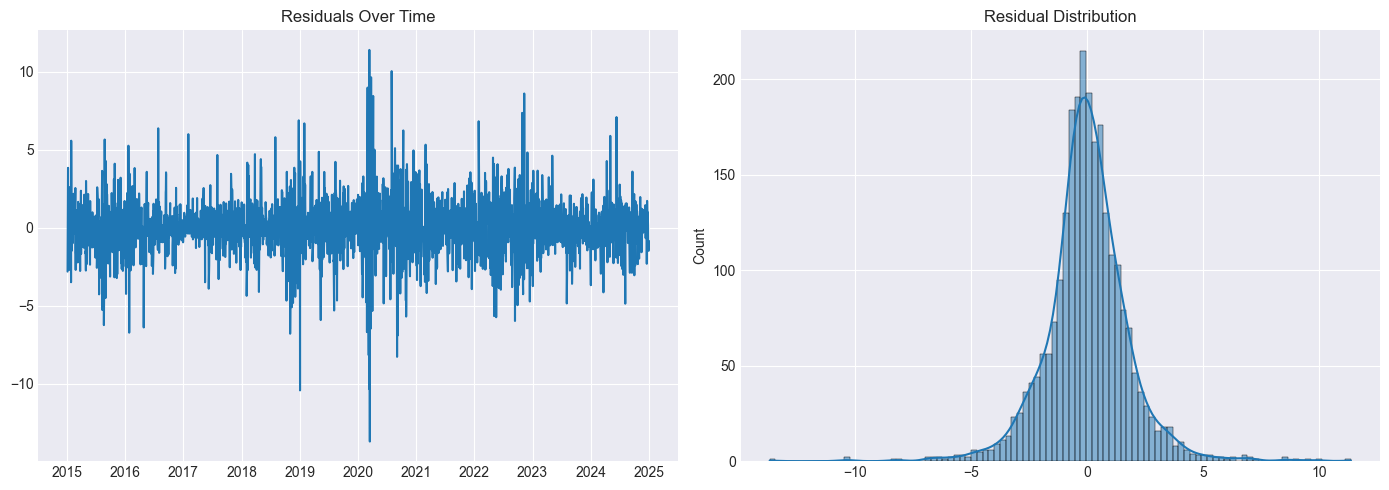

In [16]:
residuals = results.resid

fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].plot(residuals)
ax[0].set_title('Residuals Over Time')

sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

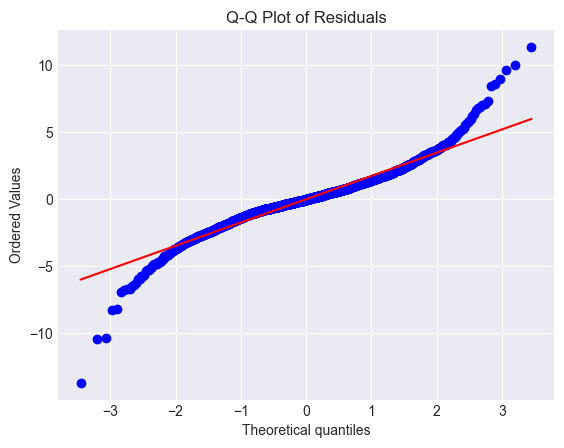

In [17]:
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

<Figure size 1000x500 with 0 Axes>

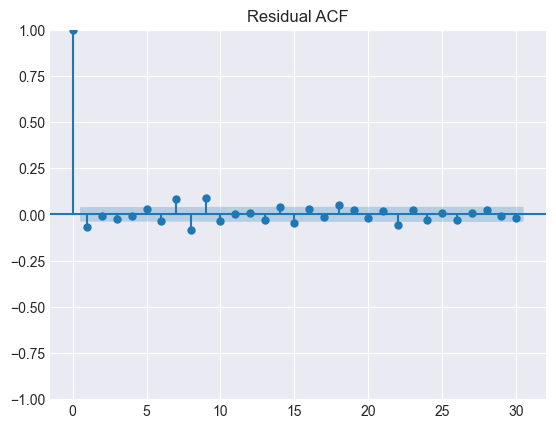

In [18]:
plt.figure(figsize=(10,5))
plot_acf(residuals.dropna(), lags=30)
plt.title('Residual ACF')
plt.show()

In [19]:
model_3 = MarkovRegression(
    returns,
    k_regimes=3,
    trend='c',
    switching_variance=True
).fit()

C:\Users\oriol\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\oriol\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [20]:
comparison = pd.DataFrame({
    'Model': ['GARCH(1,1)', '2 Regimes', '3 Regimes'],
    'AIC': [garch_result.aic, results.aic, model_3.aic],
    'BIC': [garch_result.bic, results.bic, model_3.bic]
})

print(comparison)

        Model          AIC          BIC
0  GARCH(1,1)  9586.219019  9609.539131
1   2 Regimes  9507.407662  9542.387831
2   3 Regimes  9431.691638  9501.651975


The two-regime Markov switching model mildly outperformed the GARCH(1,1) benchmark, reducing the AIC from 9586.22 to 9507.41 and the BIC from 9609.54 to 9542.39. 

Although the three-regime model achieved slightly lower information criteria (AIC = 9431.69, BIC = 9501.65), the improvement over the two-regime model was relatively modest.

## 8. Model Weakness

---

### 3 - Regimes Markov Switching Model
One limitation of the 2-regime Markov switching model is that it may oversimplify the behavior of stock returns by forcing all market conditions into only two states (low- and high-volatility). The lower AIC and BIC values of the 3-regime model suggest that additional market states may exist and are not fully captured by the 2-regime specification.

### Stationary Test
A further weakness is that no formal stationarity test was conducted before estimation. Although stock returns are generally assumed to be stationary, failing to verify this means the model may be applied to data that do not fully satisfy its assumptions, potentially affecting the reliability of the estimated regimes.

### Feature Extraction
In addition, no feature selection or additional explanatory variables were included. The model relies only on historical returns, so it may omit important information such as lagged returns, trading volume, volatility measures, or macroeconomic indicators that could improve regime identification and predictive performance.

### Data limitation
Due to the limited sample size, out-of-sample validation was not conducted as splitting the data would compromise regime estimation. This remains a limitation of the current analysis.

## 9. Model Improvement

---

### Stationary Test

In [21]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(returns.dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -15.549459096162769
p-value: 2.1091374614121553e-28


In [22]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(returns.dropna(), regression='c')
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

C:\Users\oriol\AppData\Local\Temp\ipykernel_11944\3754766244.py:3: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




KPSS Statistic: 0.06275492129083872
p-value: 0.1


#### Interpretation:

- ADF p < 0.05 → stationary
- KPSS p < 0.05 → non-stationary

The stationarity tests indicate that the return series is stationary.

### Feature Extraction

We improve regime detection by using volatility-based and momentum-based features.
Added .shift(1) to avoid look ahead bias

In [23]:
features = pd.DataFrame(index=returns.index)

features["returns"]    = returns

features["vol_5"]      = returns.rolling(5).std().shift(1)
features["vol_21"]     = returns.rolling(21).std().shift(1)
features["momentum_5"] = returns.rolling(5).mean().shift(1)

features = features.dropna()

### Removing Outliers

In [24]:
features_clean = features.copy()

for col in features_clean.columns:
    lower = features_clean[col].quantile(0.01)
    upper = features_clean[col].quantile(0.99)
    
    features_clean[col] = features_clean[col].clip(lower=lower, upper=upper)

X = features_clean[["vol_5", "vol_21", "momentum_5"]]
y = features_clean["returns"]

### Multicollinearity Check

The VIF values are below 10 for all features.

In [25]:
features.corr()

,returns,vol_5,vol_21,momentum_5
returns,1.000000,-0.037554,-0.007126,-0.029165
vol_5,-0.037554,1.000000,0.718205,-0.154914
vol_21,-0.007126,0.718205,1.000000,-0.062854
momentum_5,-0.029165,-0.154914,-0.062854,1.000000


In [26]:
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

      feature       VIF
0       vol_5  7.593746
1      vol_21  7.649463
2  momentum_5  1.027123


## 10. Final Model

The model was built after checking that the series is stationary, creating additional features, removing outliers, and testing for multicollinearity to make sure the variables are not redundant.

In [27]:
final_model = MarkovRegression(
    y,
    k_regimes=2,
    exog=X,
    trend='c',
    switching_variance=True
)

final_result = final_model.fit()
print(final_result.summary())

C:\Users\oriol\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



                        Markov Switching Model Results                        
Dep. Variable:                returns   No. Observations:                 2494
Model:               MarkovRegression   Log Likelihood               -4582.137
Date:                Mon, 20 Apr 2026   AIC                           9188.274
Time:                        17:49:50   BIC                           9258.133
Sample:                             0   HQIC                          9213.639
                               - 2494                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2213      0.119     -1.864      0.062      -0.454       0.011
x1             0.0946      0.073      1.288      0.1

In [28]:
f_comparison = pd.DataFrame({
    'Model': ['Benchmark (GARCH)', '2 Regimes', '2 Regimes (Final Model)'],
    'AIC': [garch_result.aic, results.aic, final_result.aic],
    'BIC': [garch_result.bic, results.bic, final_result.bic]
})

print(f_comparison)

                     Model          AIC          BIC
0        Benchmark (GARCH)  9586.219019  9609.539131
1                2 Regimes  9507.407662  9542.387831
2  2 Regimes (Final Model)  9188.273633  9258.133351


## 11. Deployment 

This model can be deployed in financial systems for:
- Market crash detection
- Volatility regime monitoring
- Dynamic portfolio allocation
- Trading signal generation
- Risk management dashboards

Example Decision Rule:

In [29]:
f_smoothed_probs = final_result.smoothed_marginal_probabilities
latest_prob = f_smoothed_probs[1].iloc[-1]

if latest_prob > 0.70:
    print("ALERT: High-volatility regime detected")
else:
    print("Market stable")

Market stable


## 12. Conclusion

The final 2-regime specification significantly improves model fit compared to both the GARCH(1,1) benchmark and the initial Markov switching model.

The benchmark GARCH(1,1) model produces AIC and BIC values of **9586.22** and **9609.54**, respectively. The initial 2-regime model already shows improvement, reducing the AIC and BIC to **9507.41** and **9542.39**. However, the final 2-regime model delivers a substantial gain in performance, achieving the lowest information criteria with an AIC of **9188.27** and a BIC of **9258.13**.

The large reduction in both AIC and BIC indicates that the inclusion of feature engineering and data preprocessing substantially enhances the model’s ability to capture the underlying regime dynamics in the return series.

*Note: GARCH and Markov Switching models use different likelihood functions, so AIC values are not strictly comparable across model families*